**Task 1: Upload Dataset**

In [2]:
import pandas as pd

df = pd.read_csv('//content/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**Task 2: Import Required Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

**Task 3: Understand Dataset Structure**

In [4]:
df.shape

(1000, 8)

In [5]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Task 4: Check Missing Values**

In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


**Task 5: Check Duplicate Records**

In [10]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

**Task 6: Analyze Gender Distribution**

In [11]:
df['gender'].value_counts()

,count
gender,
female,518
male,482


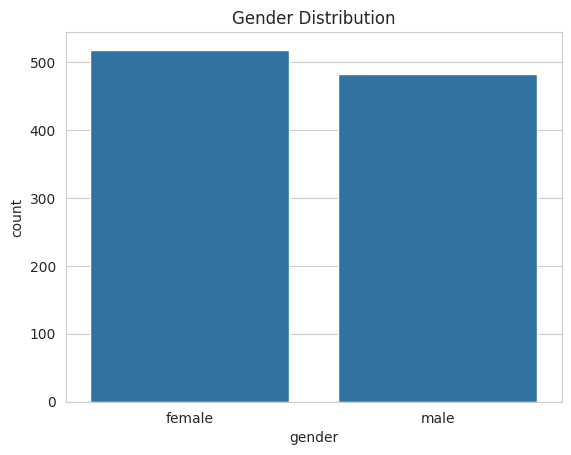

In [12]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

**Task 7: Analyze Race/Ethnicity**

In [13]:
df['race/ethnicity'].value_counts()

,count
race/ethnicity,
group C,319
group D,262
group B,190
group E,140
group A,89


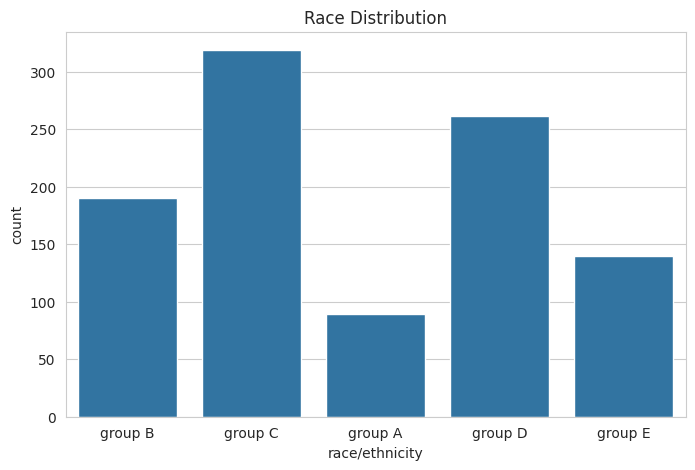

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='race/ethnicity', data=df)
plt.title("Race Distribution")
plt.show()

**Task 8: Analyze Parental Education**

In [15]:
df['parental level of education'].value_counts()

,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


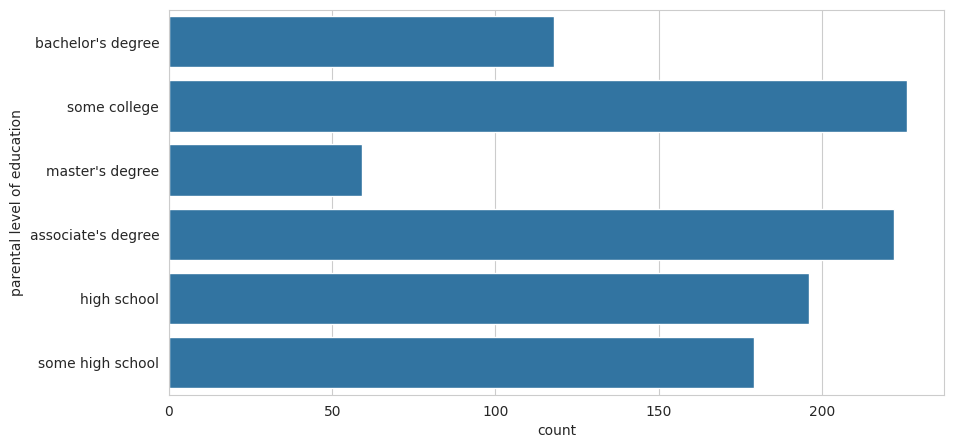

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(y='parental level of education', data=df)
plt.show()

**Task 9: Distribution of Scores**

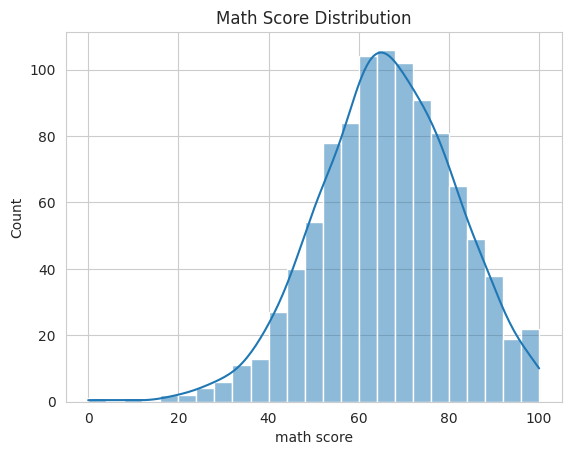

In [17]:
sns.histplot(df['math score'], kde=True)
plt.title("Math Score Distribution")
plt.show()

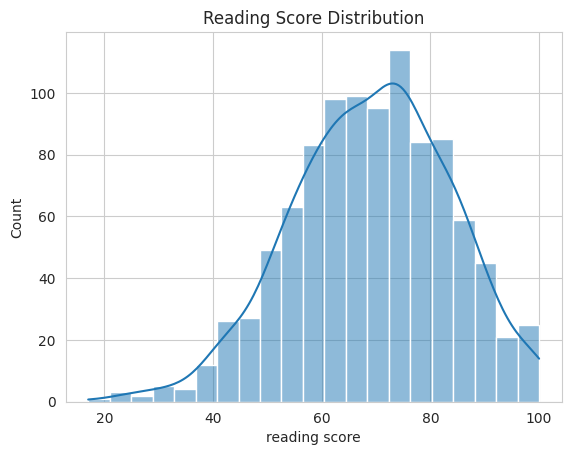

In [18]:
sns.histplot(df['reading score'], kde=True)
plt.title("Reading Score Distribution")
plt.show()

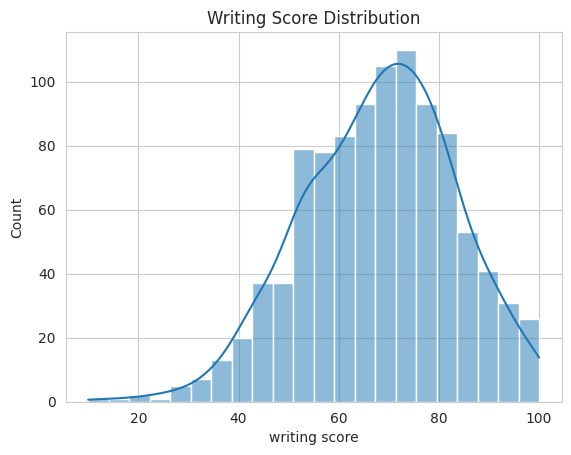

In [19]:
sns.histplot(df['writing score'], kde=True)
plt.title("Writing Score Distribution")
plt.show()

**Task 10: Compare Male and Female Scores**

In [20]:
df.groupby('gender')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


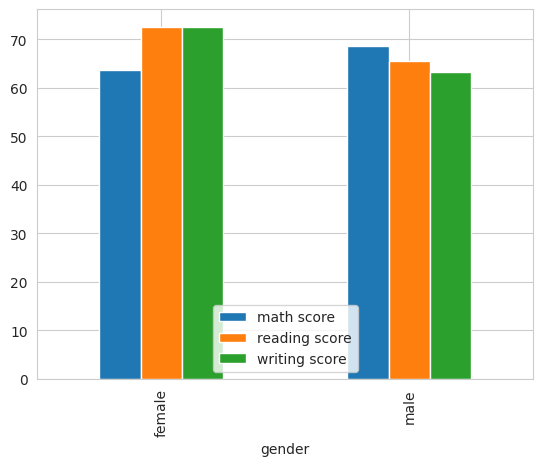

In [21]:
df.groupby('gender')[['math score','reading score','writing score']].mean().plot(kind='bar')
plt.show()

**Task 11: Lunch Effect on Performance**

In [22]:
df.groupby('lunch')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


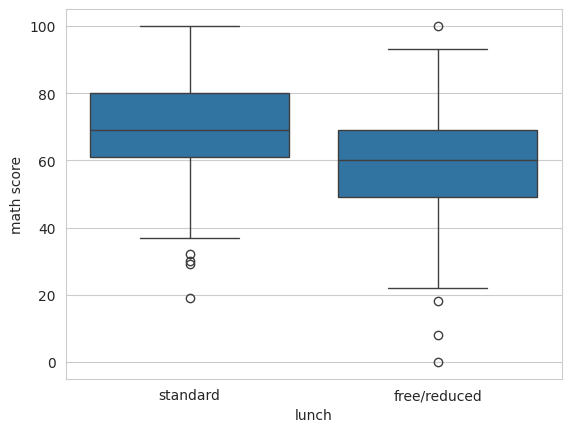

In [23]:
sns.boxplot(x='lunch', y='math score', data=df)
plt.show()

**Task 12: Test Preparation Course Analysis**

In [24]:
df.groupby('test preparation course')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


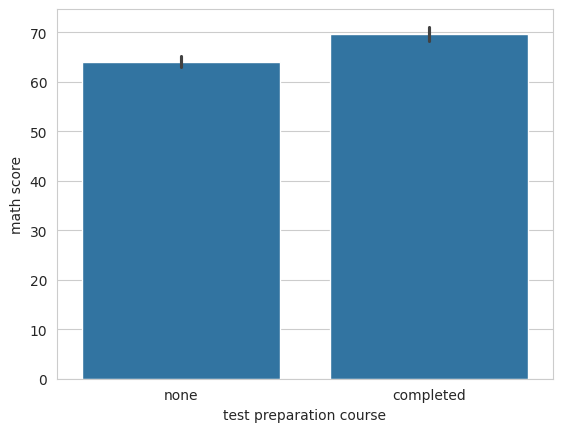

In [25]:
sns.barplot(
    x='test preparation course',
    y='math score',
    data=df
)
plt.show()

**Task 13: Correlation Analysis**

In [26]:
corr = df[['math score','reading score','writing score']].corr()
corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


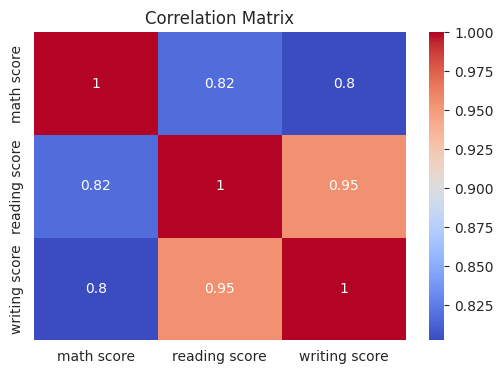

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Task 14: Pairplot**

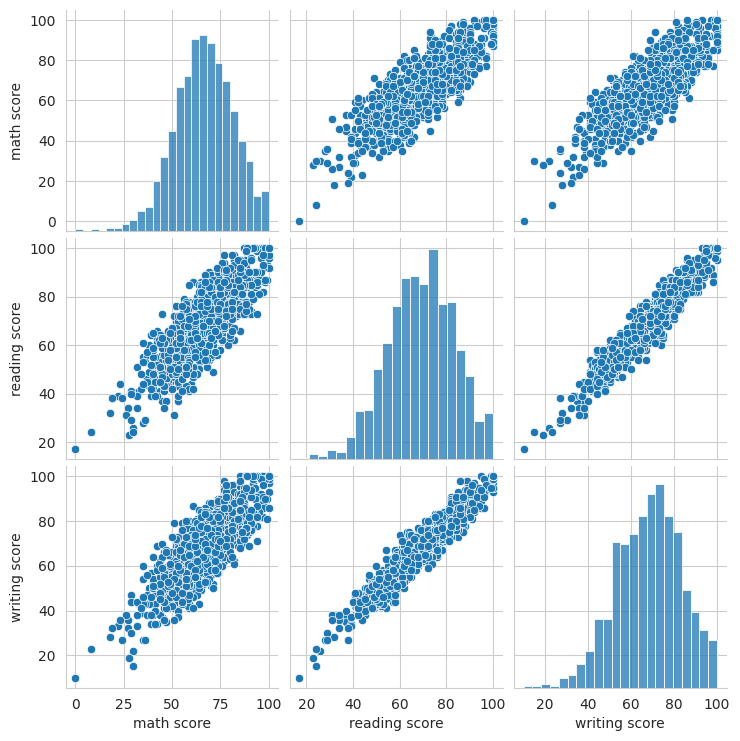

In [28]:
sns.pairplot(df[['math score','reading score','writing score']])
plt.show()

**Task 15: Create Average Score Column**

In [29]:
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)/3

In [30]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


**Task 16: Top Performers**

In [31]:
top_students = df.sort_values(
    by='average_score',
    ascending=False
)

top_students.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,100.000000
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667
712,female,group D,some college,standard,none,98,100,99,99.000000
179,female,group D,some high school,standard,completed,97,100,100,99.000000
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667
625,male,group D,some college,standard,completed,100,97,99,98.666667
685,female,group E,master's degree,standard,completed,94,99,100,97.666667
903,female,group D,bachelor's degree,free/reduced,completed,93,100,100,97.666667


**Task 17: Score Category**

In [32]:
def category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 60:
        return "Good"
    else:
        return "Needs Improvement"

df['Performance'] = df['average_score'].apply(category)

In [33]:
df['Performance'].value_counts()

,count
Performance,
Good,517
Needs Improvement,285
Excellent,198


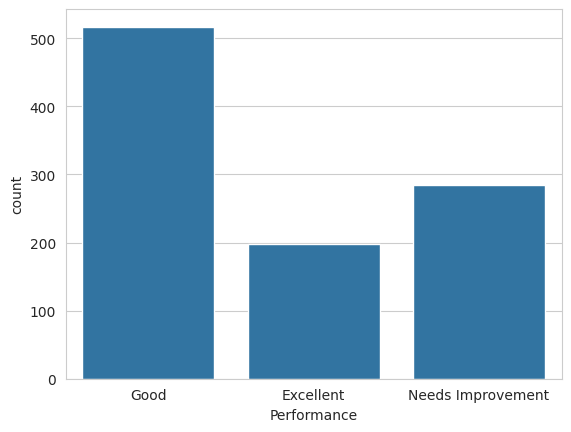

In [34]:
sns.countplot(x='Performance', data=df)
plt.show()